In [17]:
!pip install scikit-learn pandas numpy matplotlib seaborn

✅ Dataset Loaded Successfully!

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   Ave

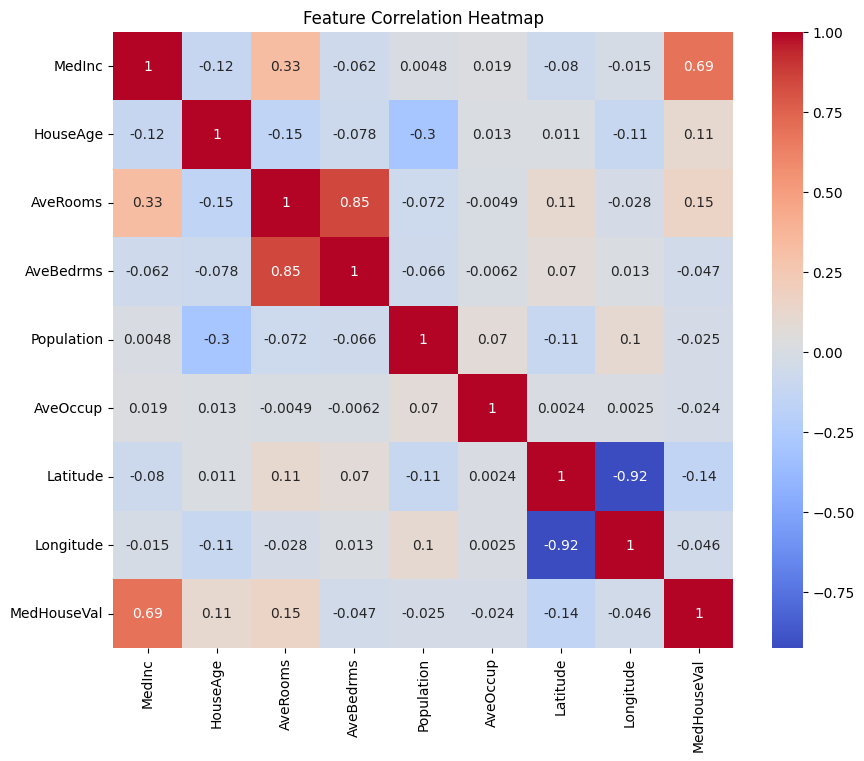


🔹 Linear Regression Metrics:
MAE  : 0.5332
MSE  : 0.5559
RMSE : 0.7456
R²   : 0.5758

🔹 Polynomial Regression Metrics:
MAE  : 0.4670
MSE  : 0.4643
RMSE : 0.6814
R²   : 0.6457

📘 Cross-Validation (R² Scores): [0.54866323 0.46820691 0.55078434 0.53698703 0.66051406]
Mean CV R²: 0.5530311140279561

🔧 Best Ridge Alpha: {'alpha': 10}
Best Ridge R²: 0.5530925208131402

🔧 Best Lasso Alpha: {'alpha': 0.01}
Best Lasso R²: 0.5497644182002727


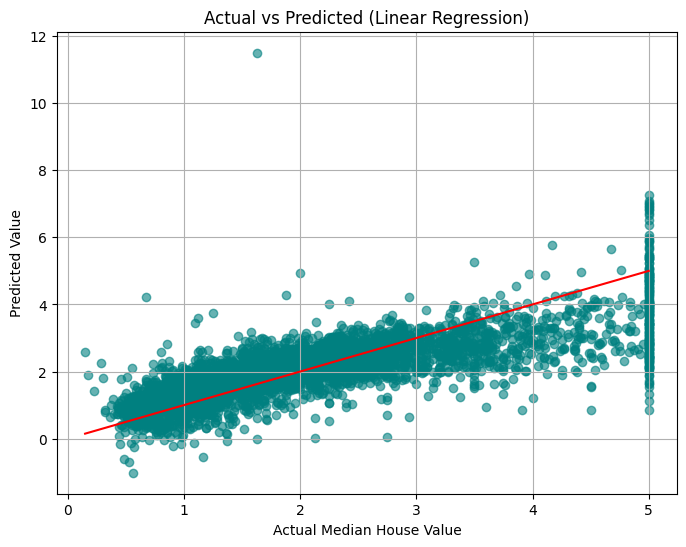


📊 Regression Metrics Summary:

                   Model       MAE       MSE      RMSE  R² Score
0      Linear Regression  0.533200  0.555892  0.745581  0.575788
1  Polynomial Regression  0.467001  0.464302  0.681397  0.645682


In [18]:
# =====================================
# 🏠 California Housing - Regression Project (Upgraded)
# =====================================

# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================
# Load Dataset
# =====================================
housing = fetch_california_housing(as_frame=True)
df = housing.frame
print("✅ Dataset Loaded Successfully!\n")
print(df.head())

# =====================================
# Data Exploration
# =====================================
print("\n📊 Dataset Info:")
print(df.info())

print("\n📈 Statistical Summary:")
print(df.describe())

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# =====================================
# Feature Scaling
# =====================================
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =====================================
# Train-Test Split
# =====================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# =====================================
# Linear Regression
# =====================================
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# --- Regression Metrics ---
lr_mae = mean_absolute_error(y_test, y_pred)
lr_mse = mean_squared_error(y_test, y_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, y_pred)

print("\n🔹 Linear Regression Metrics:")
print(f"MAE  : {lr_mae:.4f}")
print(f"MSE  : {lr_mse:.4f}")
print(f"RMSE : {lr_rmse:.4f}")
print(f"R²   : {lr_r2:.4f}")

# =====================================
# Polynomial Regression
# =====================================
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_scaled)
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train_poly)
y_pred_poly = poly_model.predict(X_test_poly)

# --- Regression Metrics ---
poly_mae = mean_absolute_error(y_test_poly, y_pred_poly)
poly_mse = mean_squared_error(y_test_poly, y_pred_poly)
poly_rmse = np.sqrt(poly_mse)
poly_r2 = r2_score(y_test_poly, y_pred_poly)

print("\n🔹 Polynomial Regression Metrics:")
print(f"MAE  : {poly_mae:.4f}")
print(f"MSE  : {poly_mse:.4f}")
print(f"RMSE : {poly_rmse:.4f}")
print(f"R²   : {poly_r2:.4f}")

# =====================================
# Cross-Validation (Linear Regression)
# =====================================
cv_scores = cross_val_score(lr, X_scaled, y, cv=5, scoring='r2')
print("\n📘 Cross-Validation (R² Scores):", cv_scores)
print("Mean CV R²:", np.mean(cv_scores))

# =====================================
# Hyperparameter Tuning – Ridge & Lasso
# =====================================
params = {'alpha': [0.01, 0.1, 1, 10, 100]}

ridge = GridSearchCV(Ridge(), params, cv=5)
ridge.fit(X_scaled, y)
print("\n🔧 Best Ridge Alpha:", ridge.best_params_)
print("Best Ridge R²:", ridge.best_score_)

lasso = GridSearchCV(Lasso(max_iter=10000), params, cv=5)
lasso.fit(X_scaled, y)
print("\n🔧 Best Lasso Alpha:", lasso.best_params_)
print("Best Lasso R²:", lasso.best_score_)

# =====================================
# Visualize Predictions
# =====================================
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Value")
plt.title("Actual vs Predicted (Linear Regression)")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r')
plt.grid(True)
plt.show()

# =====================================
# Metrics Summary Table
# =====================================
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Polynomial Regression'],
    'MAE': [lr_mae, poly_mae],
    'MSE': [lr_mse, poly_mse],
    'RMSE': [lr_rmse, poly_rmse],
    'R² Score': [lr_r2, poly_r2]
})

print("\n📊 Regression Metrics Summary:\n")
print(results)
